In [1]:
# part 4 - Handover Iterative Variational Quantum Eigensover
# fills a similar purpose to the standard QVE, but is changed up to fit scalability better by "handing over" tasks for breakdowns

# If needed:
# !pip install qiskit scipy numpy
import numpy as np
from scipy.optimize import minimize
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, SparsePauliOp

# Hamiltonian
H = SparsePauliOp.from_list([
    ('ZI', 1.0),
    ('IZ', 1.0),
    ('XX', 0.5)
])

# --------------------------------------------------
# Ansatz builder
# --------------------------------------------------
def build_ansatz(params, stage):
    qc = QuantumCircuit(2)

    # Stage 1: single-qubit rotations
    qc.ry(params[0], 0)
    qc.ry(params[1], 1)

    if stage >= 2:
        qc.cx(0, 1)

    if stage >= 3:
        qc.ry(params[2], 0)
        qc.ry(params[3], 1)

    return qc

# --------------------------------------------------
# Energy function
# --------------------------------------------------
def energy(params, stage):
    qc = build_ansatz(params, stage)
    state = Statevector.from_instruction(qc)
    return state.expectation_value(H).real

# --------------------------------------------------
# Iterative optimization
# --------------------------------------------------
np.random.seed(42)

stage_params = {
    1: 2,
    2: 2,
    3: 4,
}

best_params = None
energy_history = []

for stage in [1, 2, 3]:
    print(f'\n=== Stage {stage} ===')

    n_params = stage_params[stage]

    if best_params is None:
        initial = 2 * np.pi * np.random.random(n_params)
    else:
        if n_params > len(best_params):
            extra = np.zeros(n_params - len(best_params))
            initial = np.concatenate([best_params, extra])
        else:
            initial = best_params[:n_params]

    result = minimize(
        lambda x: energy(x, stage),
        initial,
        method='COBYLA',
        options={'maxiter': 200}
    )

    best_params = result.x
    best_energy = result.fun
    energy_history.append(best_energy)

    print('Energy:', best_energy)
    print('Parameters:', best_params)

print('\nEnergy history:')
print(energy_history)


=== Stage 1 ===
Energy: -1.9999999996345805
Parameters: [3.14157026 9.42477032]

=== Stage 2 ===
Energy: -2.061552811875268
Parameters: [ 3.38657201 12.56641447]

=== Stage 3 ===
Energy: -2.061552811875268
Parameters: [ 3.38657201 12.56641447  0.          0.        ]

Energy history:
[np.float64(-1.9999999996345805), np.float64(-2.061552811875268), np.float64(-2.061552811875268)]


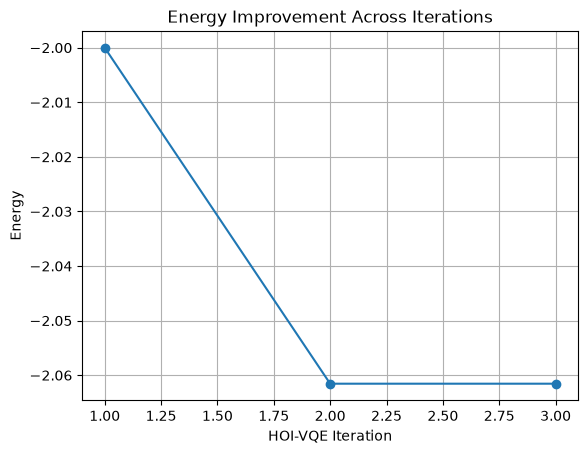

In [2]:
import matplotlib.pyplot as plt

plt.plot(range(1, len(energy_history)+1), energy_history, marker='o')
plt.xlabel('HOI-VQE Iteration')
plt.ylabel('Energy')
plt.title('Energy Improvement Across Iterations')
plt.grid(True)
plt.show()


===== Stage 1 =====
Energy: -1.9999999989521968
Parameters: [3.14164339 3.14155445]

===== Stage 2 =====
Energy: -2.061552811605277
Parameters: [3.38659863 6.28321523]

===== Stage 3 =====
Energy: -2.061552811605277
Parameters: [3.38659863 6.28321523 0.         0.        ]


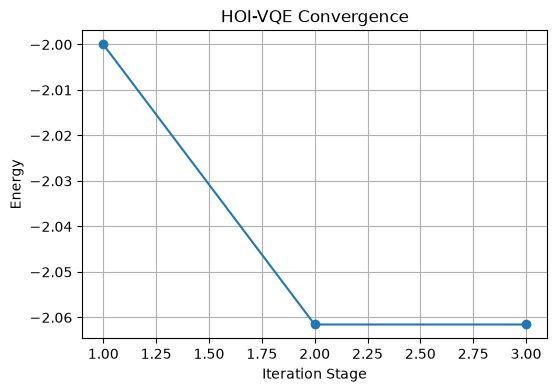

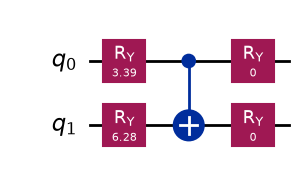

In [4]:
# Full code: Hand-Over Iterative VQE (HOI-VQE)

# !pip install qiskit scipy numpy matplotlib

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, SparsePauliOp

# Hamiltonian
H = SparsePauliOp.from_list([
    ('ZI', 1.0),
    ('IZ', 1.0),
    ('XX', 0.5)
])


def build_ansatz(params, stage):
    qc = QuantumCircuit(2)

    qc.ry(params[0], 0)
    qc.ry(params[1], 1)

    if stage >= 2:
        qc.cx(0, 1)

    if stage >= 3:
        qc.ry(params[2], 0)
        qc.ry(params[3], 1)

    return qc


def compute_energy(params, stage):
    qc = build_ansatz(params, stage)
    state = Statevector.from_instruction(qc)
    return state.expectation_value(H).real


stage_param_counts = {1: 2, 2: 2, 3: 4}
np.random.seed(7)

best_params = None
energy_history = []

for stage in [1, 2, 3]:
    print(f'\n===== Stage {stage} =====')

    n_params = stage_param_counts[stage]

    if best_params is None:
        initial_params = 2 * np.pi * np.random.random(n_params)
    else:
        if n_params > len(best_params):
            initial_params = np.concatenate(
                [best_params, np.zeros(n_params - len(best_params))]
            )
        else:
            initial_params = best_params[:n_params]

    result = minimize(
        lambda x: compute_energy(x, stage),
        initial_params,
        method='COBYLA',
        options={'maxiter': 200}
    )

    best_params = result.x
    best_energy = result.fun

    energy_history.append(best_energy)

    print('Energy:', best_energy)
    print('Parameters:', best_params)

# Plot convergence
plt.figure(figsize=(6, 4))
plt.plot(range(1, len(energy_history)+1), energy_history, marker='o')
plt.xlabel('Iteration Stage')
plt.ylabel('Energy')
plt.title('HOI-VQE Convergence')
plt.grid(True)
plt.show()

# Draw final circuit
final_circuit = build_ansatz(best_params, 3)
display(final_circuit.draw(output='mpl', style='iqp'))